In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time
import numpy as np
from ultralytics import YOLO
from IPython.display import display, Video

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style="whitegrid")

runs_dir = 'runs' 

det_models_paths = {
    'YOLOv8n (Detect)': os.path.join(runs_dir, 'detect/train_yolov8n'),
    'YOLOv9c (Detect)': os.path.join(runs_dir, 'detect/train_yolov9c'),
    'YOLOv10n (Detect)': os.path.join(runs_dir, 'detect/train_yolov10n')
}

seg_models_paths = {
    'YOLOv8n-Seg': os.path.join(runs_dir, 'segment/yolov8n-seg_run'),
    'YOLOv8s-Seg': os.path.join(runs_dir, 'segment/yolov8s-seg_run'),
    'YOLOv9c-Seg': os.path.join(runs_dir, 'segment/yolov9c-seg_run')
}

all_models_paths = {**det_models_paths, **seg_models_paths}

print("Шляхи налаштовано. Готові до аналізу.")

Шляхи налаштовано. Готові до аналізу.


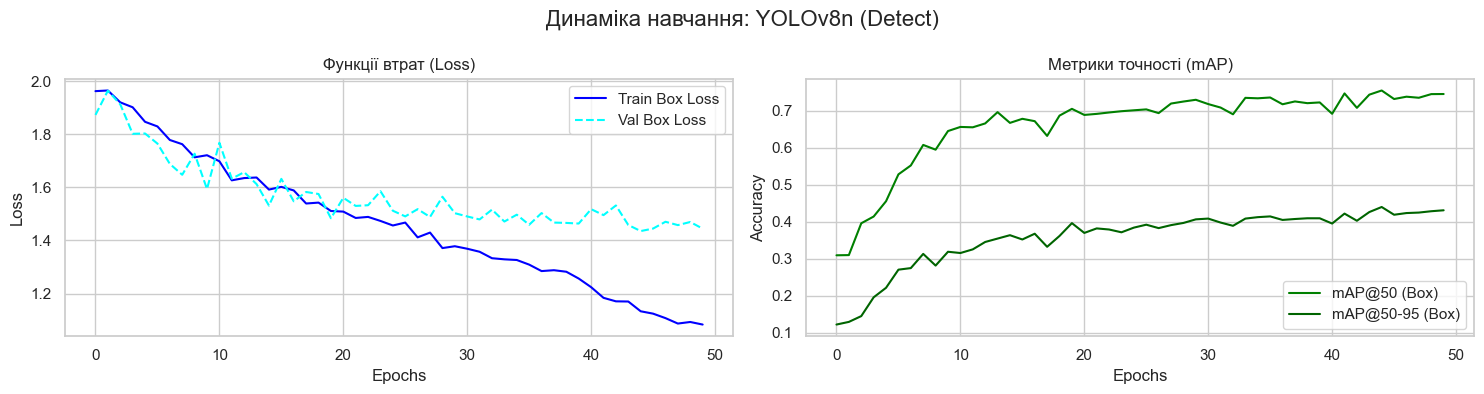

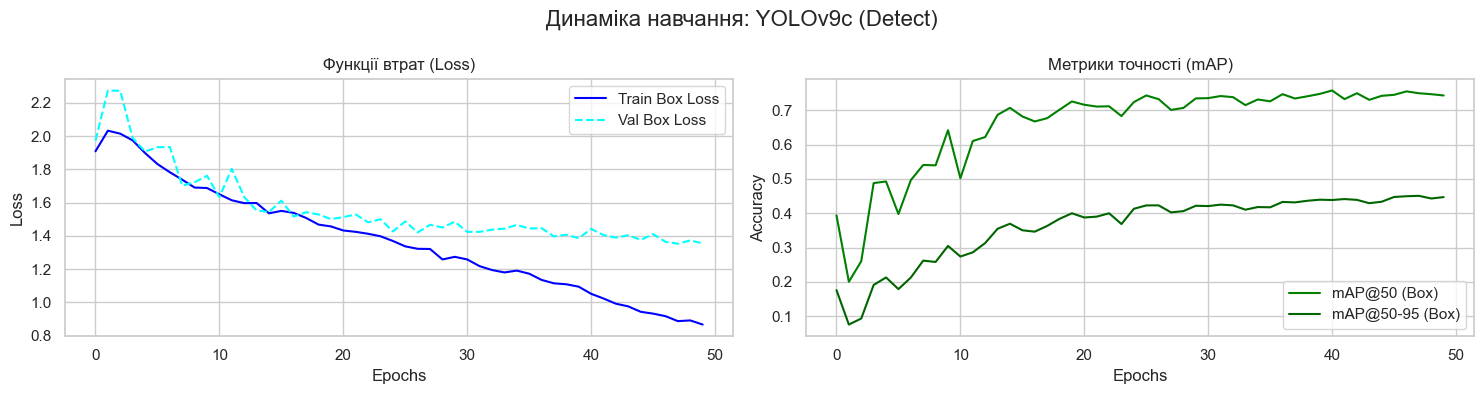

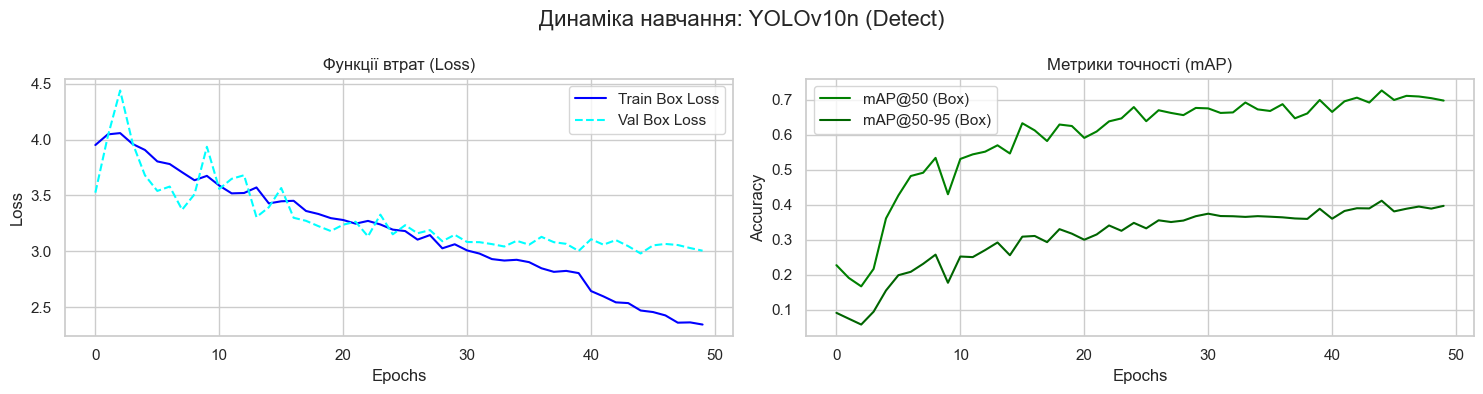

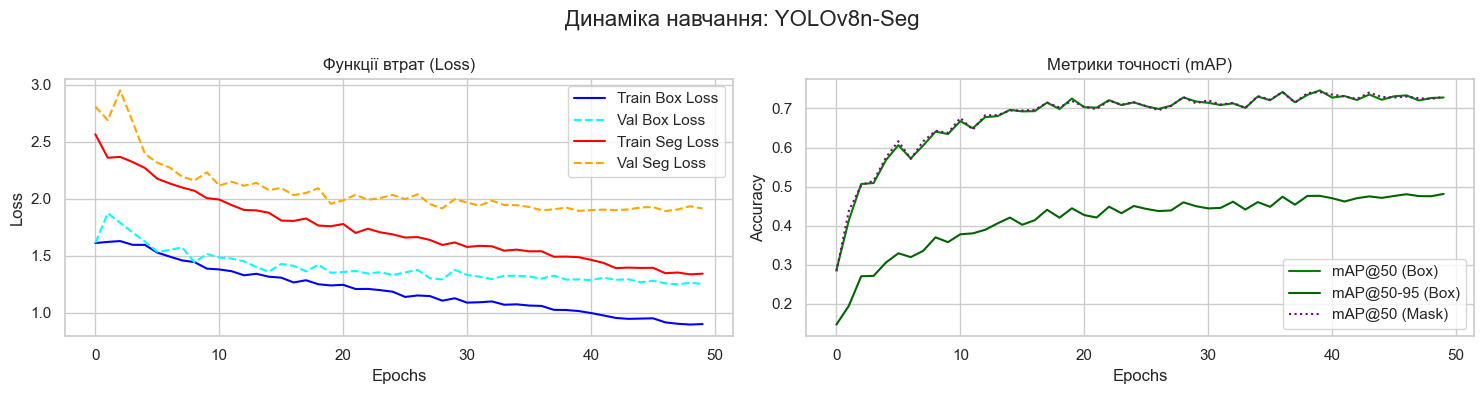

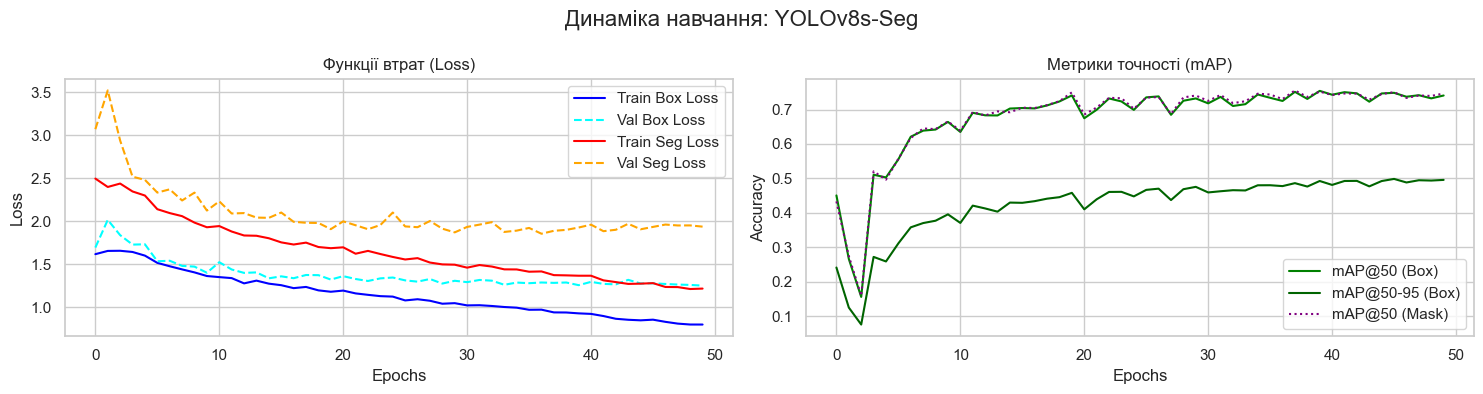

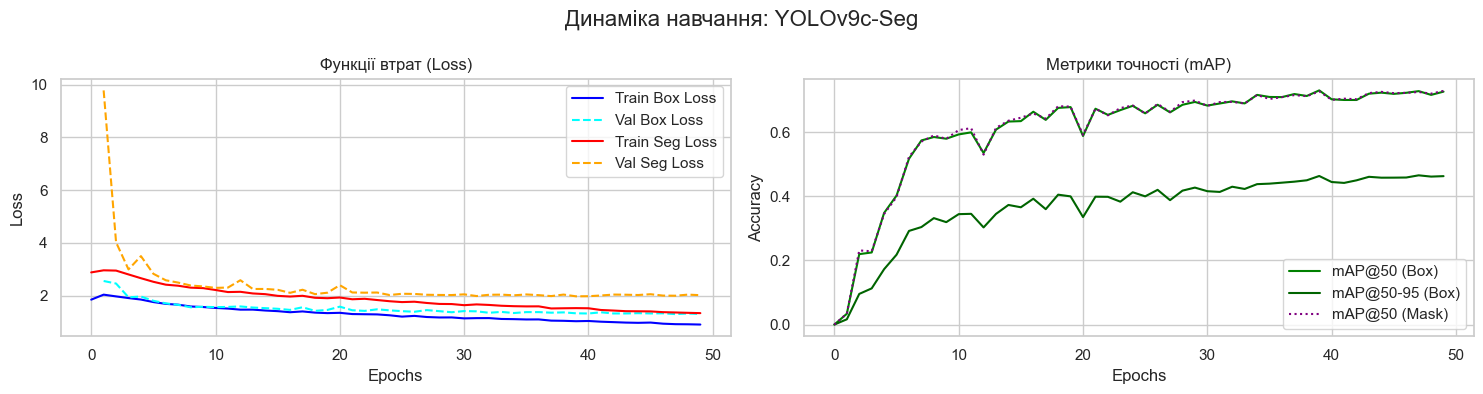

In [6]:
def plot_training_curves(models_dict):
    for name, path in models_dict.items():
        csv_file = os.path.join(path, 'results.csv')
        
        if not os.path.exists(csv_file):
            print(f"⚠️ Файл не знайдено: {csv_file}")
            continue
            
        df = pd.read_csv(csv_file)
        df.columns = df.columns.str.strip() # Видаляємо зайві пробіли
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        fig.suptitle(f'Динаміка навчання: {name}', fontsize=16)
        
        # 1. Графік Loss (Box vs Seg)
        axes[0].plot(df['train/box_loss'], label='Train Box Loss', color='blue')
        axes[0].plot(df['val/box_loss'], label='Val Box Loss', color='cyan', linestyle='--')
        
        # Якщо це сегментація, додаємо Seg Loss
        if 'train/seg_loss' in df.columns:
            axes[0].plot(df['train/seg_loss'], label='Train Seg Loss', color='red')
            axes[0].plot(df['val/seg_loss'], label='Val Seg Loss', color='orange', linestyle='--')
            
        axes[0].set_title('Функції втрат (Loss)')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        
        # 2. Графік mAP (Точність)
        # Визначаємо правильну колонку (вона може відрізнятися у v8/v10)
        map50_col = 'metrics/mAP50(B)' if 'metrics/mAP50(B)' in df.columns else 'metrics/mAP50'
        map5095_col = 'metrics/mAP50-95(B)' if 'metrics/mAP50-95(B)' in df.columns else 'metrics/mAP50-95'
        
        axes[1].plot(df[map50_col], label='mAP@50 (Box)', color='green')
        axes[1].plot(df[map5095_col], label='mAP@50-95 (Box)', color='darkgreen')
        
        if 'metrics/mAP50(M)' in df.columns:
             axes[1].plot(df['metrics/mAP50(M)'], label='mAP@50 (Mask)', color='purple', linestyle=':')
        
        axes[1].set_title('Метрики точності (mAP)')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

# Запускаємо побудову
plot_training_curves(all_models_paths)

--- Зведена таблиця ефективності моделей ---


,Model,Type,Precision,Recall,mAP@50 (Box),mAP@50-95 (Box),mAP@50 (Mask)
0,YOLOv8n (Detect),Detection,0.757,0.716,0.755,0.439,-
1,YOLOv9c (Detect),Detection,0.796,0.691,0.750,0.451,-
2,YOLOv10n (Detect),Detection,0.734,0.715,0.727,0.412,-
3,YOLOv8n-Seg,Segmentation,0.795,0.661,0.728,0.481,0.73
4,YOLOv8s-Seg,Segmentation,0.784,0.686,0.748,0.499,0.75
5,YOLOv9c-Seg,Segmentation,0.797,0.653,0.728,0.466,0.726


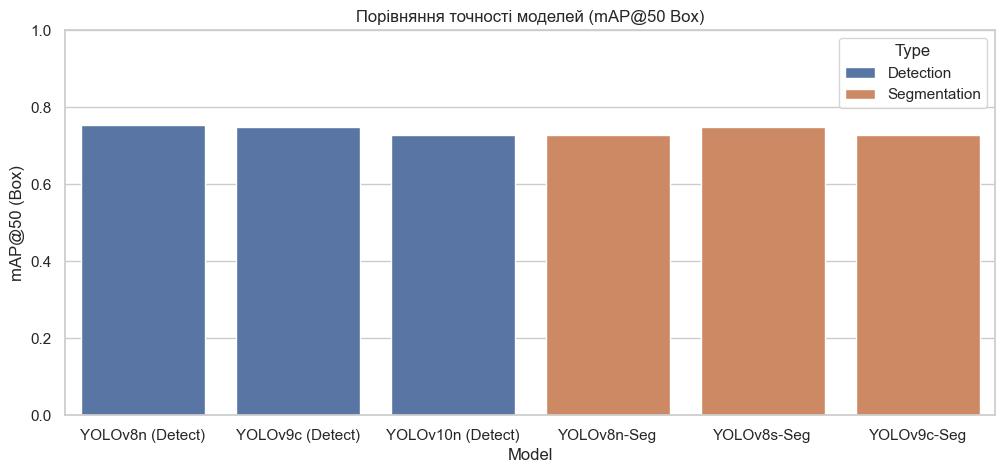

In [7]:
results_data = []

for name, path in all_models_paths.items():
    csv_file = os.path.join(path, 'results.csv')
    if not os.path.exists(csv_file): continue
        
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.strip()
    
    # Беремо найкращу епоху по mAP50-95
    map_col = 'metrics/mAP50-95(B)' if 'metrics/mAP50-95(B)' in df.columns else 'metrics/mAP50-95'
    best_idx = df[map_col].idxmax()
    best_epoch = df.iloc[best_idx]
    
    # Збираємо дані
    row = {
        'Model': name,
        'Type': 'Segmentation' if 'Seg' in name else 'Detection',
        'Precision': round(best_epoch.get('metrics/precision(B)', 0), 3),
        'Recall': round(best_epoch.get('metrics/recall(B)', 0), 3),
        'mAP@50 (Box)': round(best_epoch.get('metrics/mAP50(B)', best_epoch.get('metrics/mAP50')), 3),
        'mAP@50-95 (Box)': round(best_epoch.get(map_col), 3),
        'mAP@50 (Mask)': round(best_epoch.get('metrics/mAP50(M)', 0), 3) if 'Seg' in name else '-'
    }
    results_data.append(row)

# Створюємо DataFrame
comparison_df = pd.DataFrame(results_data)
print("--- Зведена таблиця ефективності моделей ---")
display(comparison_df)

# Візуалізація порівняння (Bar Chart)
plt.figure(figsize=(12, 5))
sns.barplot(data=comparison_df, x='Model', y='mAP@50 (Box)', hue='Type')
plt.title('Порівняння точності моделей (mAP@50 Box)')
plt.ylim(0, 1.0)
plt.show()

YOLOv8n (Detect): 149.4 FPS
YOLOv9c (Detect): 85.7 FPS
YOLOv10n (Detect): 137.2 FPS
YOLOv8n-Seg: 128.7 FPS
YOLOv8s-Seg: 128.6 FPS
YOLOv9c-Seg: 77.1 FPS


/tmp/ipykernel_3379404/122439357.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fps_df, x='Model', y='FPS', palette='viridis')


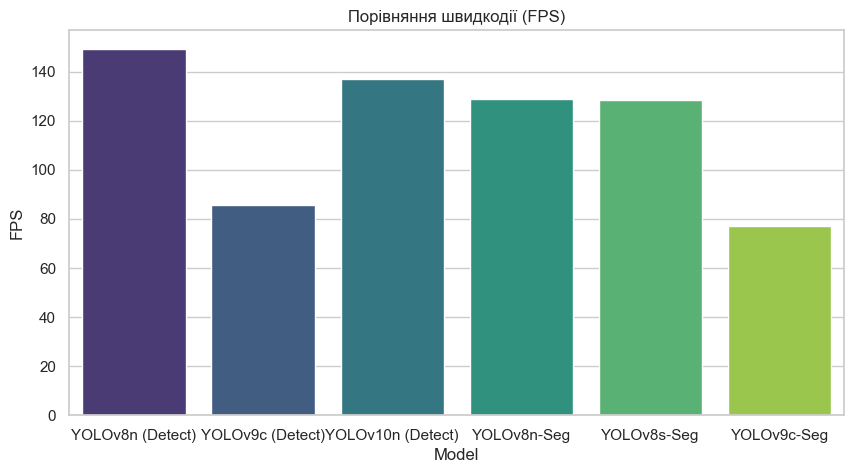

In [10]:
test_image_path = 'test/test.jpg' 

if not os.path.exists(test_image_path):
    print(f"⚠️ Завантажте тестове фото і вкажіть шлях до нього! (Поточний: {test_image_path})")
else:
    fps_data = []
    
    for name, path in all_models_paths.items():
        weights_path = os.path.join(path, 'weights', 'best.pt')
        if not os.path.exists(weights_path): continue
            
        model = YOLO(weights_path)
        
        for _ in range(5): model(test_image_path, verbose=False)
        
        start_time = time.time()
        for _ in range(50): 
            model(test_image_path, verbose=False)
        end_time = time.time()
        
        fps = 50 / (end_time - start_time)
        fps_data.append({'Model': name, 'FPS': round(fps, 1)})
        print(f"{name}: {fps:.1f} FPS")

    fps_df = pd.DataFrame(fps_data)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=fps_df, x='Model', y='FPS', palette='viridis')
    plt.title('Порівняння швидкодії (FPS)')
    plt.show()

In [11]:
video_path = 'test/tank_uknown_forest.mp4' 
output_path = 'test/final_mvp_result.mp4'

mvp_model_path = seg_models_paths['YOLOv8n-Seg'] + '/weights/best.pt'

if not os.path.exists(video_path):
    print("⚠️ Будь ласка, завантажте відеофайл для тестування!")
elif not os.path.exists(mvp_model_path):
    print("⚠️ Ваги моделі не знайдено.")
else:
    print(f"🚀 Запуск генерації MVP відео з моделлю: {mvp_model_path}")
    
    model = YOLO(mvp_model_path)
    cap = cv2.VideoCapture(video_path)
    
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    frame_count = 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        results = model(frame, conf=0.4, verbose=False)
        
        annotated_frame = results[0].plot() 
        
        cv2.putText(annotated_frame, f"MVP System | Model: YOLOv8n-Seg", (20, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        out.write(annotated_frame)
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Оброблено кадрів: {frame_count}/{total_frames}")
            
    cap.release()
    out.release()
    print(f"\n✅ ВІДЕО ГОТОВО! Збережено як: {output_path}")
    print("Завантажте файл та додайте до презентації.")

🚀 Запуск генерації MVP відео з моделлю: runs/segment/yolov8n-seg_run/weights/best.pt
Оброблено кадрів: 30/1528
Оброблено кадрів: 60/1528
Оброблено кадрів: 90/1528
Оброблено кадрів: 120/1528
Оброблено кадрів: 150/1528
Оброблено кадрів: 180/1528
Оброблено кадрів: 210/1528
Оброблено кадрів: 240/1528
Оброблено кадрів: 270/1528
Оброблено кадрів: 300/1528
Оброблено кадрів: 330/1528
Оброблено кадрів: 360/1528
Оброблено кадрів: 390/1528
Оброблено кадрів: 420/1528
Оброблено кадрів: 450/1528
Оброблено кадрів: 480/1528
Оброблено кадрів: 510/1528
Оброблено кадрів: 540/1528
Оброблено кадрів: 570/1528
Оброблено кадрів: 600/1528
Оброблено кадрів: 630/1528
Оброблено кадрів: 660/1528
Оброблено кадрів: 690/1528
Оброблено кадрів: 720/1528
Оброблено кадрів: 750/1528
Оброблено кадрів: 780/1528
Оброблено кадрів: 810/1528
Оброблено кадрів: 840/1528
Оброблено кадрів: 870/1528
Оброблено кадрів: 900/1528
Оброблено кадрів: 930/1528
Оброблено кадрів: 960/1528
Оброблено кадрів: 990/1528
Оброблено кадрів: 1020/1528

In [4]:
import cv2
import numpy as np
import time
from ultralytics import YOLO
import os

# --- НАЛАШТУВАННЯ ---
video_source = 'test/test24.MP4'
output_file = 'MVP_24.mp4'
model_path = 'runs/segment/yolov8n-seg_run/weights/best.pt'

# Колір маски (BGR) - Червоний (ворожа техніка)
MASK_COLOR = (0, 0, 255) 
ALPHA = 0.4 

if not os.path.exists(video_source):
    print(f"❌ Помилка: Відео файл не знайдено: {video_source}")
    exit()

print(f"Завантаження моделі: {model_path}...")
model = YOLO(model_path)
cap = cv2.VideoCapture(video_source)

# Отримуємо параметри вхідного потоку
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
original_fps = int(cap.get(cv2.CAP_PROP_FPS))

# Ініціалізація запису
out = cv2.VideoWriter(output_file, cv2.VideoWriter_fourcc(*'mp4v'), original_fps, (w, h))

print("🎬 Початок обробки потоку...")

while cap.isOpened():
    start_time = time.time() # Початок заміру часу кадру
    
    ret, frame = cap.read()
    if not ret: break
    
    overlay = frame.copy()
    
    # --- ГОЛОВНИЙ ЕТАП: ІНФЕРЕНС ---
    # imgsz=640 - стабілізує розмір входу для кращої детекції дрібних об'єктів
    # persist=True - критично для відео, щоб ID об'єкта не стрибав
    results = model.track(frame, persist=True, imgsz=640, conf=0.4, verbose=False)
    
    # Перевірка наявності детекцій
    if results[0].masks is not None:
        raw_masks = results[0].masks.data.cpu().numpy()
        
        for i, raw_mask in enumerate(raw_masks):
            # 1. Якісне масштабування маски (INTER_LINEAR краще для згладжування)
            mask = cv2.resize(raw_mask, (w, h), interpolation=cv2.INTER_LINEAR)
            
            # 2. Жорсткий поріг (Thresholding) для чітких країв
            _, binary_mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)
            binary_mask = binary_mask.astype(np.uint8)
            
            # 3. Заливка
            overlay[binary_mask == 1] = MASK_COLOR
            
            # 4. Контур
            contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(frame, contours, -1, (0, 255, 0), 2) 

    # Змішування шарів
    frame = cv2.addWeighted(overlay, ALPHA, frame, 1 - ALPHA, 0)

    # --- HUD ІНТЕРФЕЙС ---
    # Розрахунок реального FPS обробки (Inference speed)
    process_time = time.time() - start_time
    real_fps = 1 / process_time if process_time > 0 else 0
    
    # Дизайн інтерфейсу
    cv2.putText(frame, "TARGET ACQUISITION", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    
    # Виводимо Реальний FPS (наскільки швидко працює система) vs FPS Відео
    cv2.putText(frame, f"System FPS: {real_fps:.1f} | Stream FPS: {original_fps}", (30, 85), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 255, 200), 1)
    
    cv2.putText(frame, f"Model: YOLOv8n-Seg | Mode: Tracking", (30, 110), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (150, 150, 150), 1)
    
    # Приціл
    cx, cy = w // 2, h // 2
    gap = 10
    length = 25
    cv2.line(frame, (cx - length, cy), (cx - gap, cy), (255, 255, 255), 1)
    cv2.line(frame, (cx + gap, cy), (cx + length, cy), (255, 255, 255), 1)
    cv2.line(frame, (cx, cy - length), (cx, cy - gap), (255, 255, 255), 1)
    cv2.line(frame, (cx, cy + gap), (cx, cy + length), (255, 255, 255), 1)
    cv2.circle(frame, (cx, cy), 2, (0, 0, 255), -1) # Червона крапка в центрі

    out.write(frame)

cap.release()
out.release()
print(f"✅ Готово! Файл збережено: {output_file}")

Завантаження моделі: runs/segment/yolov8n-seg_run/weights/best.pt...
🎬 Початок обробки потоку...
✅ Готово! Файл збережено: MVP_24.mp4


✅ Завантаження моделі та вибір 4 випадкових фото...


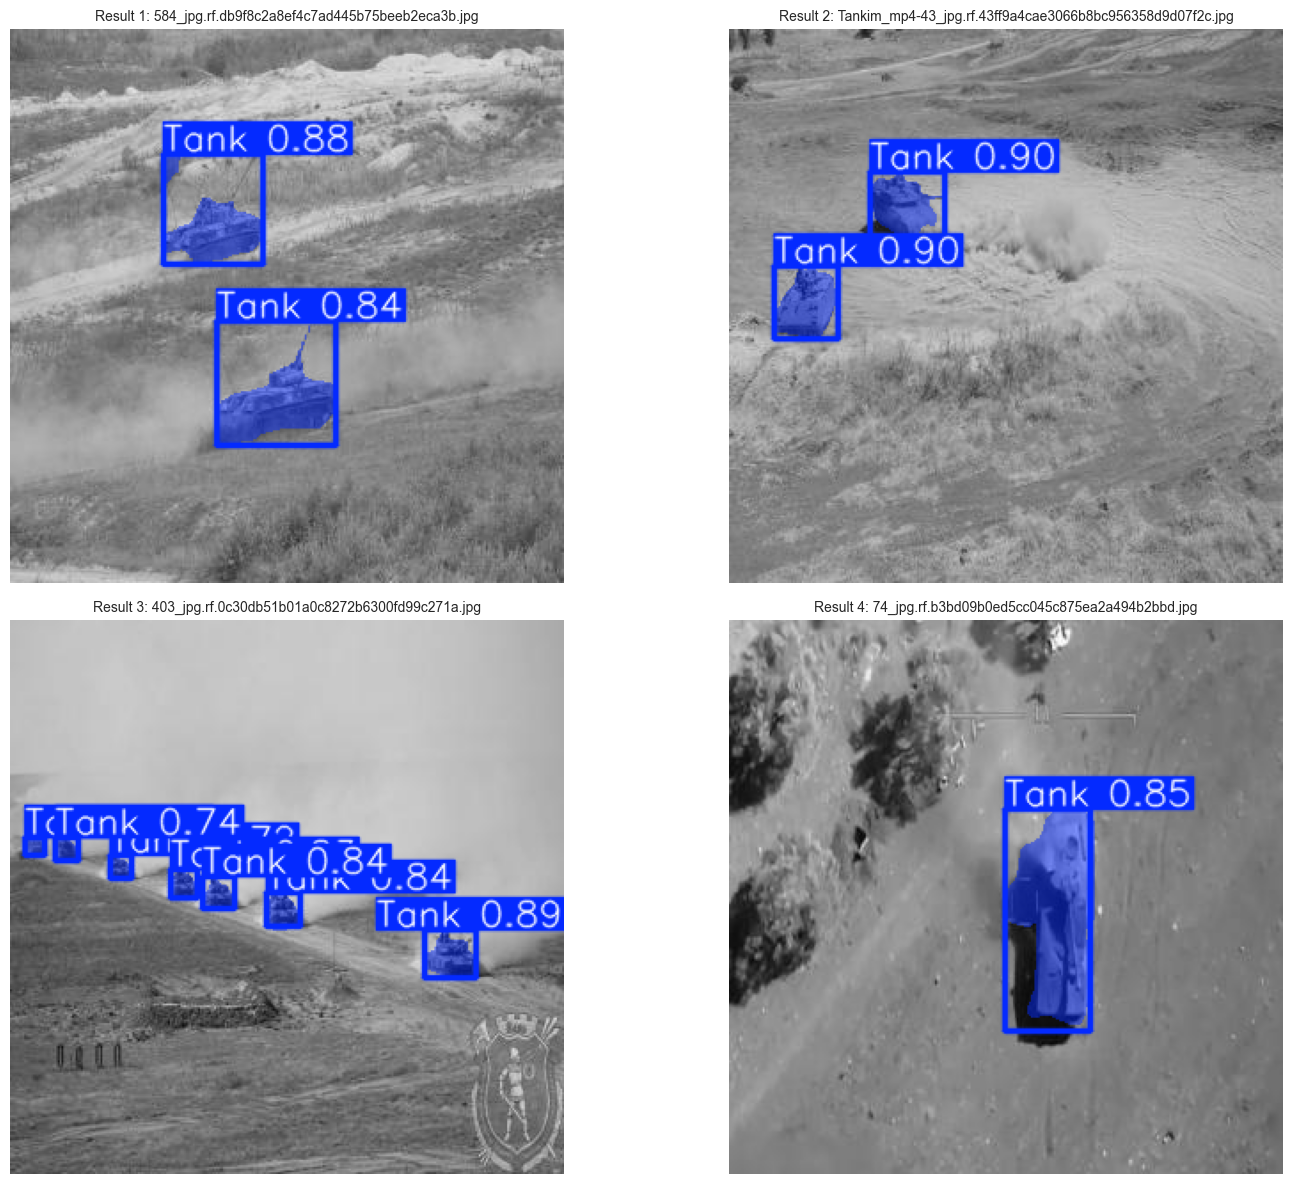

In [21]:
import matplotlib.pyplot as plt
import cv2
import os
import random
import glob
from ultralytics import YOLO

# --- НАЛАШТУВАННЯ ---
# 1. Шлях до вашої найкращої моделі
model_path = 'runs/segment/yolov8n-seg_run/weights/best.pt'

# 2. Шлях до папки з тестовими фото (зазвичай це valid/images або test/images)
# Перевірте, де саме у вас лежать картинки датасету
test_images_dir = '/home/obahlai/Documents/detection_segmentation/Mil_Vechicle_Segmentation-1/valid/images'

# Кількість прикладів для показу
NUM_SAMPLES = 4 

# --- ПЕРЕВІРКА ---
if not os.path.exists(model_path):
    print(f"❌ Помилка: Не знайдено модель за шляхом: {model_path}")
elif not os.path.exists(test_images_dir):
    print(f"❌ Помилка: Не знайдено папку з фото: {test_images_dir}")
else:
    print(f"✅ Завантаження моделі та вибір {NUM_SAMPLES} випадкових фото...")
    
    # Завантажуємо модель
    model = YOLO(model_path)
    
    # Шукаємо всі картинки (.jpg, .png, .jpeg)
    image_files = glob.glob(os.path.join(test_images_dir, '*.*'))
    images_to_show = [f for f in image_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(images_to_show) < NUM_SAMPLES:
        print(f"⚠️ У папці мало фото ({len(images_to_show)}), показуємо всі.")
        samples = images_to_show
    else:
        # Вибираємо випадкові
        samples = random.sample(images_to_show, NUM_SAMPLES)
    
    # Налаштування розміру фігури (ширина, висота)
    plt.figure(figsize=(16, 12))
    
    for i, img_path in enumerate(samples):
        # Інференс
        # conf=0.4 — поріг впевненості (можна підняти до 0.5)
        # iou=0.5 — поріг перекриття
        results = model(img_path, conf=0.4, iou=0.5, verbose=False)
        
        # Отримуємо картинку з намальованими боксами/масками
        res_plot = results[0].plot(line_width=2, font_size=1.2)
        
        # Конвертуємо BGR (OpenCV) -> RGB (Matplotlib) для коректних кольорів
        res_rgb = cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB)
        
        # Додаємо у сітку
        plt.subplot(2, 2, i + 1) # (рядки, колонки, номер)
        plt.imshow(res_rgb)
        plt.axis('off') # Прибираємо осі координат
        plt.title(f"Result {i+1}: {os.path.basename(img_path)}", fontsize=10)

    plt.tight_layout()
    plt.show()